## Trajectory inference - pseudotime using PAGA (scanpy)

- last updated: 5/20/2025
- The goal is to infer the trajectory using PAGA for the peak UMAP


In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import sys
import os

# rapids-singlecell
import cupy as cp
import rapids_singlecell as rsc

/home/yang-joon.kim/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/yang-joon.kim/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/yang-joon.kim/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/yang-joon.kim/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/yang-joon.kim/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecat

In [2]:
# figure parameter setting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
mpl.rcParams.update(mpl.rcParamsDefault) #Reset rcParams to default

# Editable text and proper LaTeX fonts in illustrator
# matplotlib.rcParams['ps.useafm'] = True
# Editable fonts. 42 is the magic number
mpl.rcParams['pdf.fonttype'] = 42
sns.set(style='whitegrid', context='paper')
# Set default DPI for saved figures
mpl.rcParams['savefig.dpi'] = 600

In [3]:
import logging
# Suppress INFO-level logs for the entire logger
logging.getLogger().setLevel(logging.WARNING)

In [4]:
# define the figure path
figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/peak_umap_annotated/"
os.makedirs(figpath, exist_ok=True)
sc.settings.figdir = figpath

In [5]:
# import the peaks-by-celltype&timepoint pseudobulk object
adata_peaks = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_pb_leiden_0.4_merged_annotated_filtered.h5ad")
adata_peaks

AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',

## Step 1. Running PAGA (implemented in scanpy)

- https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.paga.html
- NOTE. PAGA uses neighborhoods to compute the abstracted "graph"

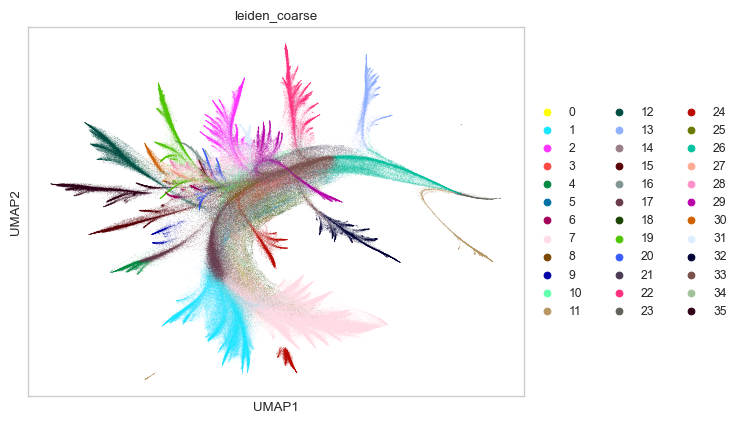

In [16]:
# check the UMAP
sc.pl.umap(adata_peaks, color="leiden_coarse")

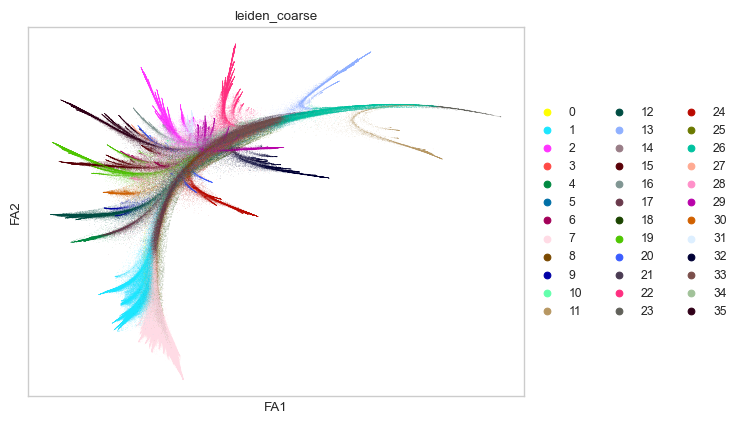

In [15]:
# plot a force-directed graph
rsc.tl.draw_graph(adata_peaks, init_pos="X_umap_2D")
sc.pl.draw_graph(adata_peaks, color="leiden_coarse")

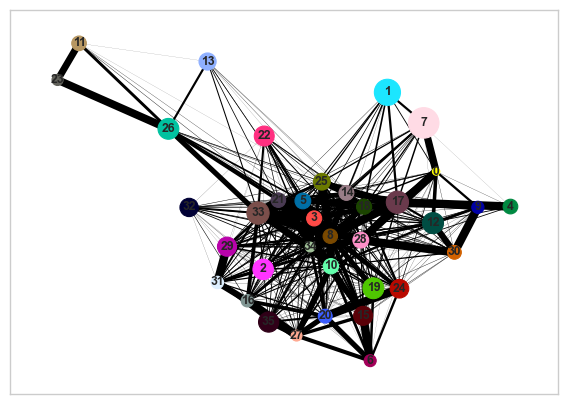

In [6]:
sc.tl.paga(adata_peaks, groups = "leiden_coarse")
sc.pl.paga(adata_peaks)

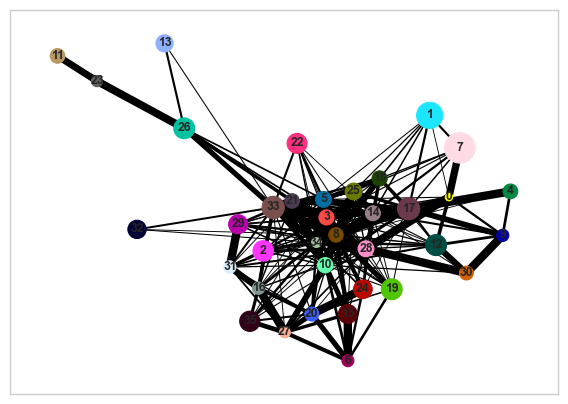

In [12]:
sc.pl.paga(adata_peaks, threshold=0.1)

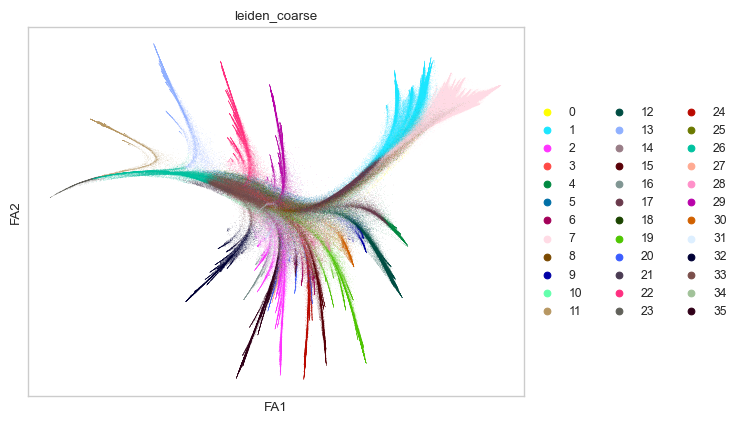

In [39]:
# regenrate the 2D embedding using PAGA
rsc.tl.draw_graph(adata_peaks, init_pos='paga')
sc.pl.draw_graph(adata_peaks, color="leiden_coarse")

In [27]:
# Compute the Diffusion Pseudotime
adata_peaks.uns["iroot"] = np.flatnonzero(adata_peaks.obs["leiden_coarse"]==23)[-1]
sc.tl.dpt(adata_peaks)

In [26]:
adata_peaks.obsm["X_draw_graph_fa"][np.flatnonzero(adata_peaks.obs["leiden_coarse"]==23)]

array([[-191639.34  ,    4898.8984],
       [-191969.78  ,    4932.961 ],
       [-193235.72  ,    4577.3735],
       ...,
       [-184818.86  ,    6254.2896],
       [-187249.8   ,    5805.8486],
       [-205386.77  ,    1403.8121]], dtype=float32)

In [21]:
np.flatnonzero(adata_peaks.obs["leiden_coarse"]==23)

array([    15,     22,     24, ..., 640810, 640811, 640816])

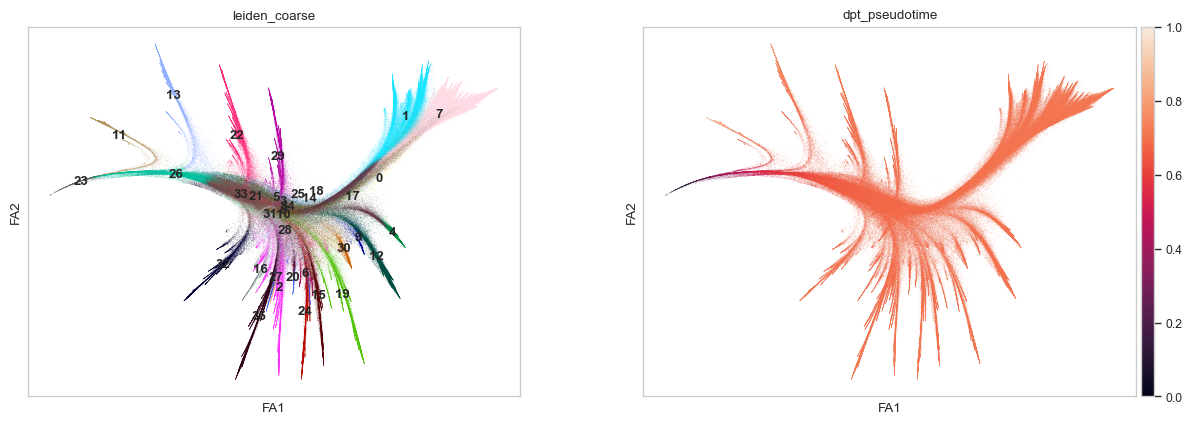

In [28]:
sc.pl.draw_graph(adata_peaks, color=["leiden_coarse","dpt_pseudotime"], legend_loc="on data")

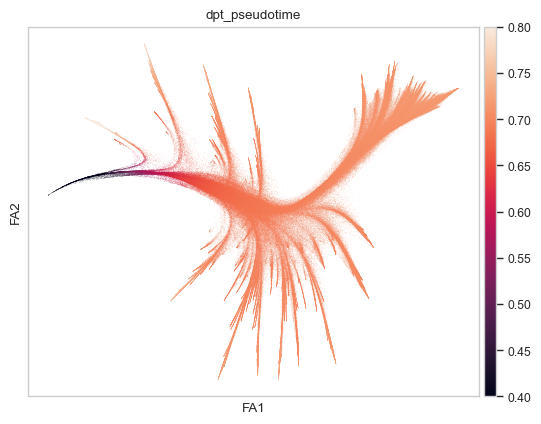

In [37]:
sc.pl.draw_graph(adata_peaks, color=["dpt_pseudotime"], vmin=0.4, vmax=0.8)

### NOTE: DPT is not good at capturing the "smooth" pseudotime along the entire trajectories (good at the initial branches, though)

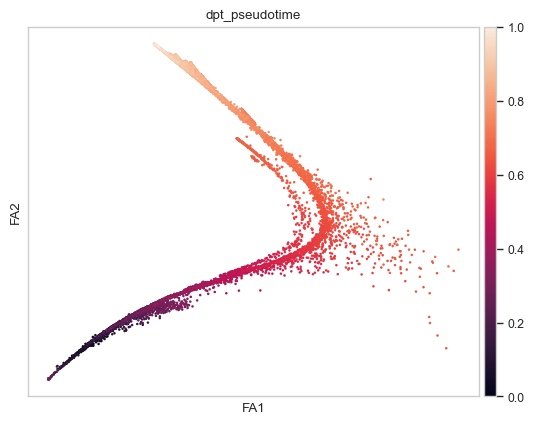

In [33]:
# subset for the initial clusters 23 and 11 and plot the pseudotime
sc.pl.draw_graph(adata_peaks[adata_peaks.obs["leiden_coarse"].isin([23, 11])], color="dpt_pseudotime")

In [38]:
# export the Diffusion Pseudotime to csv
adata_peaks.obs[["leiden_coarse","dpt_pseudotime"]].to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/dpt_pseudotime_640K_peaks.csv")